In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller, ccf
import matplotlib.dates as mdates

In [2]:
df = pd.read_parquet("../data/final/master_weekly.parquet")

In [3]:
df

,usd_php_mean,brent_mean,wti_mean,mops_gasoil_mean,mops_rbob_mean,dubai_close,cpi_value,rub_usd_mean,diesel,diesel_plus,kerosene,ron100,ron91,ron95,ron97
week_monday,,,,,,,,,,,,,,,
2018-02-12,51.383200,65.496,62.014,79.039999,74.617200,62.631000,97.9,0.017446,39.175,43.550,48.350,NaN,50.135,52.0700,54.075
2018-02-19,51.917200,62.718,60.562,76.596400,71.933401,62.631000,97.9,0.017438,38.025,41.980,45.790,NaN,49.085,50.9950,53.020
2018-02-26,52.081001,65.520,62.470,77.809500,74.358901,62.631000,97.9,0.017698,38.925,43.070,48.935,NaN,49.735,51.6700,53.675
2018-03-05,51.844800,66.024,62.070,76.870601,77.159039,63.917273,98.4,0.017777,39.175,43.430,49.735,NaN,50.195,52.1700,54.175
2018-04-23,52.051800,73.618,67.546,83.669800,86.710680,68.667143,98.8,0.016312,42.300,46.325,49.440,NaN,51.870,53.3700,55.795
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-03-30,59.841000,111.242,94.292,189.149402,130.331038,126.706364,127.2,0.012262,131.550,140.000,154.750,102.950,93.700,98.3025,107.300
2026-04-06,60.456999,123.935,105.670,204.551247,136.953600,126.706364,127.2,0.012380,147.800,155.700,163.050,104.500,94.950,97.1000,106.425
2026-04-13,59.842799,124.605,104.544,209.639999,131.521320,126.706364,127.2,0.012655,123.600,129.500,155.300,97.625,87.150,90.3000,99.050


## Data Coverage and Missingness

In [4]:
print('Null Counts Per Column')
nulls = df.isnull().sum().sort_values(ascending=False)
print(nulls[nulls > 0])
print(f'\nTotal rows: {len(df)}')
print(f'Complete rows (no nulls): {df.dropna().shape[0]}')

Null Counts Per Column
ron100         27
diesel          3
diesel_plus     3
kerosene        3
dtype: int64

Total rows: 373
Complete rows (no nulls): 346


## Pairwise Correlation Test

Per our methodology, we have three crude oil proxies. Lunor et al. (2023) implemented and held Dubai as the 'correct' benchmark for Asian refiners, but it is monthly. Brent is the literature standard and is daily. WTI is US-centric.

We resolve this empirically: if Brent and WTI correlate >0.95, they are redundant. We keep Brent (more relevant globally) and Dubai (as robustness feature, forward-filled monthly).

Crude Oil Correlation Matrix
             brent_mean  wti_mean  dubai_close
brent_mean       1.0000    0.9910       0.9661
wti_mean         0.9910    1.0000       0.9548
dubai_close      0.9661    0.9548       1.0000



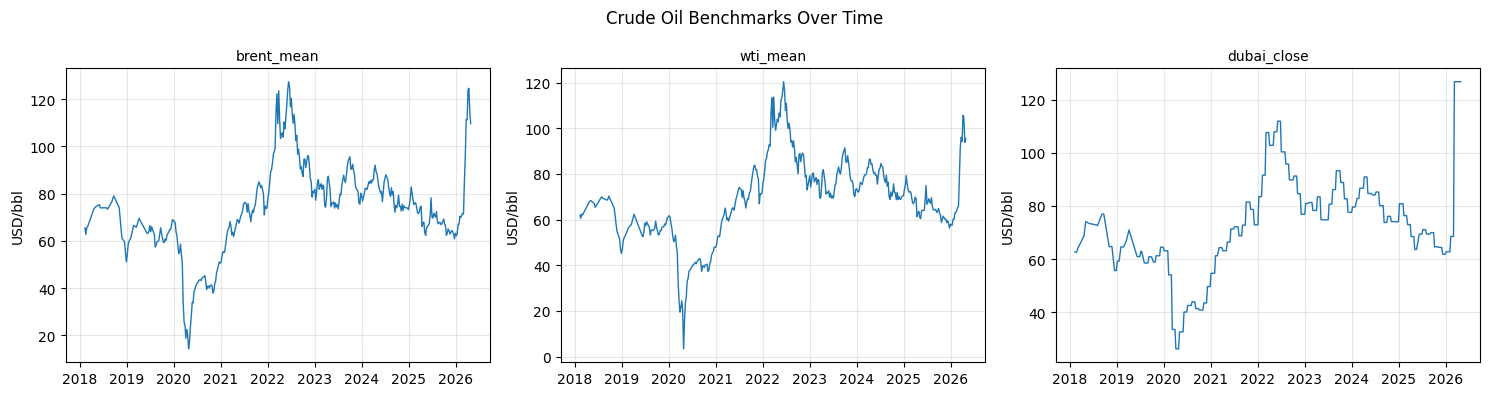

Brent-WTI correlation: 0.9910
Brent and WTI are >0.95 correlated. DROPPING WTI to avoid multicollinearity.
Keeping: Brent (primary, daily) + Dubai (robustness, monthly-ffilled)
This is consistent with Lunor et al. (2023) who used Dubai Crude as their crude feature.


In [5]:
CRUDE_ALL = ['brent_mean', 'wti_mean', 'dubai_close']
crude_available = [c for c in CRUDE_ALL if c in df.columns]
crude_df = df[crude_available].dropna()

print('Crude Oil Correlation Matrix')
print(crude_df.corr().round(4))
print()

fig, axes = plt.subplots(1, len(crude_available), figsize=(5*len(crude_available), 4))
if len(crude_available) == 1:
    axes = [axes]

for ax, col in zip(axes, crude_available):
    ax.plot(crude_df.index, crude_df[col], linewidth=1.0)
    ax.set_title(col, fontsize=10)
    ax.set_ylabel('USD/bbl')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.grid(True, alpha=0.3)

plt.suptitle('Crude Oil Benchmarks Over Time', fontsize=12)
plt.tight_layout()
plt.show()

if 'brent_mean' in crude_df and 'wti_mean' in crude_df:
    corr_bw = crude_df['brent_mean'].corr(crude_df['wti_mean'])
    print(f'Brent-WTI correlation: {corr_bw:.4f}')
    if corr_bw > 0.95:
        print('Brent and WTI are >0.95 correlated. DROPPING WTI to avoid multicollinearity.')
        print('Keeping: Brent (primary, daily) + Dubai (robustness, monthly-ffilled)')
        print('This is consistent with Lunor et al. (2023) who used Dubai Crude as their crude feature.')

## Stationarity Analysis: Augmented Dickey-Fuller (ADF) Test

Following Ljubić et al. (2023), particularly to ensure the statistical validity of our time-series models and avoid spurious regressions, we conducted ADF tests on the retail pump prices at both the Level and First Difference stages. Specifically, initial test on raw price levels suggests that all series are non-stationary, as we fail to reject the null hypothesis ($p > 0.05$). However, after applying first-differencing, all series achieved stationarity ($p < 0.01$), indicating they are integrated of order one, or $I(1)$. In simpler terms, the price series in levels are non-stationary, which motivates the use of returns/differences in feature engineering.

In [6]:
def adf_test(series, name):
    s = series.dropna()
    if len(s) < 20:
        print(f'{name:35s} | Too few observations')
        return
    result = adfuller(s, autolag='AIC')
    pval = result[1]
    stat = result[0]
    status = 'STATIONARY' if pval < 0.05 else 'NON-STATIONARY'
    print(f'{name:35s} | ADF={stat:7.3f} | p={pval:.4f} | {status}')

In [7]:
FEATURES  = ['brent_mean', 'usd_php_mean', 'mops_gasoil_mean', 'mops_rbob_mean', 'cpi_value', 'dubai_close']
feat_available = [f for f in FEATURES if f in df.columns and f != 'wti_mean']
PRODUCTS  = ['diesel', 'ron91', 'ron95', 'ron97']
available_products = [p for p in PRODUCTS if p in df.columns]
print('ADF TEST — PRICE LEVELS')
for col in available_products + feat_available:
    if col in df.columns:
        adf_test(df[col], col)

print()
print('ADF TEST — FIRST DIFFERENCES (weekly changes)')
for col in available_products + feat_available:
    if col in df.columns:
        adf_test(df[col].diff().dropna(), f'Δ{col}')

ADF TEST — PRICE LEVELS
diesel                              | ADF= -0.907 | p=0.7857 | NON-STATIONARY
ron91                               | ADF= -1.480 | p=0.5433 | NON-STATIONARY
ron95                               | ADF= -1.480 | p=0.5435 | NON-STATIONARY
ron97                               | ADF= -1.230 | p=0.6605 | NON-STATIONARY
brent_mean                          | ADF= -2.091 | p=0.2481 | NON-STATIONARY
usd_php_mean                        | ADF= -0.721 | p=0.8414 | NON-STATIONARY
mops_gasoil_mean                    | ADF= -1.424 | p=0.5707 | NON-STATIONARY
mops_rbob_mean                      | ADF= -1.694 | p=0.4341 | NON-STATIONARY
cpi_value                           | ADF= -1.122 | p=0.7062 | NON-STATIONARY
dubai_close                         | ADF= -1.715 | p=0.4232 | NON-STATIONARY

ADF TEST — FIRST DIFFERENCES (weekly changes)
Δdiesel                             | ADF= -9.383 | p=0.0000 | STATIONARY
Δron91                              | ADF= -7.940 | p=0.0000 | STATIONARY
Δ

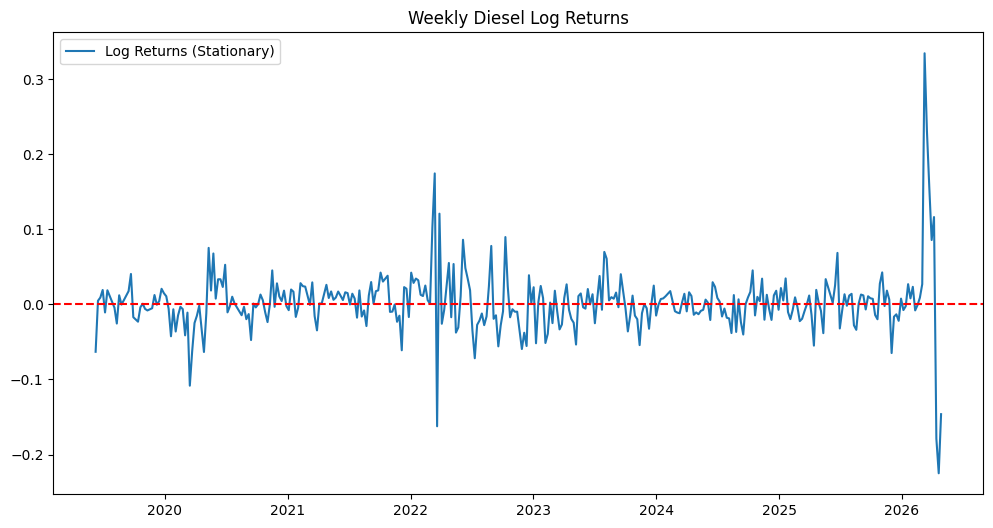

In [8]:
# Convert to Log Returns
df_stat = df.copy()
df_stat['log_return_diesel'] = np.log(df_stat['diesel'] / df_stat['diesel'].shift(1))
df_stat.dropna(inplace=True)

# Visualization of the Stationary Series
plt.figure(figsize=(12, 6))
plt.plot(df_stat.index, df_stat['log_return_diesel'], label='Log Returns (Stationary)')
plt.axhline(0, color='red', linestyle='--')
plt.title('Weekly Diesel Log Returns')
plt.legend()
plt.show()

## Lead-Lag Analysis: MOPS to Retail Pump Prices

To quantify the Oil Price Pass-Through, we utilize the Cross-Correlation Function (CCF) on first-differenced data. This identifies the specific time delay (in weeks) between a price movement in the Singapore market (MOPS) and the subsequent adjustment at Philippine pumps.

The results indicate a highly efficient transmission mechanism, with the strongest signal occurring at Lag 0.

Note on Indexing: Because MOPS values are calculated as the average of the previous week and indexed on Monday, Lag 0 represents the correlation between last week's global trade and the Tuesday pump price adjustment.

In [9]:
def get_ccf_analysis(df, feature_col, target_col, lags=6):
    # Align and Clean: Drop NaNs across both columns to ensure equal shapes
    # This prevents the 'operands could not be broadcast together' error
    df_clean = df[[feature_col, target_col]].dropna()
    
    # Difference: Transform prices (Level) to changes (First Difference)
    # We dropna again because diff() creates a NaN at the first row
    d_feat = df_clean[feature_col].diff().dropna()
    d_targ = df_clean[target_col].diff().dropna()
    
    # Calculate CCF
    ccf_values = ccf(d_feat, d_targ, nlags=lags, alpha=None)
    
    # Print Results
    print(f"CCF: {feature_col} → {target_col}")
    for i, val in enumerate(ccf_values):
        print(f"  Lag {i}: {val:.4f}")
        
    # Simple Visualization
    plt.figure(figsize=(8, 4))
    plt.stem(range(len(ccf_values)), ccf_values)
    plt.title(f"Cross-Correlation: {feature_col} vs {target_col}")
    plt.xlabel("Lags (Weeks)")
    plt.ylabel("Correlation")
    plt.show()

def get_oil_feature_mosaic(df, target_col, feature_list, lags=6):
    # Dictionary to store results
    mosaic_data = {}
    
    for feat in feature_list:
        # Align and Difference
        df_sub = df[[feat, target_col]].dropna()
        d_feat = df_sub[feat].diff().dropna()
        d_targ = df_sub[target_col].diff().dropna()
        
        # Calculate CCF and store in dict
        ccf_vals = ccf(d_feat, d_targ, nlags=lags, alpha=None)
        mosaic_data[feat] = ccf_vals
    
    # Create DataFrame: Rows = Lags, Columns = Features
    mosaic_df = pd.DataFrame(mosaic_data)
    mosaic_df.index.name = 'Lag'
    
    # Print the Table
    print(f"CCF for Target: {target_col}")
    print(mosaic_df.round(4))
    
    # Side-by-Side Comparison Plot
    mosaic_df.plot(kind='bar', figsize=(12, 5), width=0.7)
    plt.xticks(rotation=0)
    plt.title(f"Oil Feature Comparison for {target_col}")
    plt.ylabel("Correlation Coefficient")
    plt.axhline(0, color='black', linewidth=0.8)
    # plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.legend(title="Oils")
    plt.show()

CCF: mops_gasoil_mean → diesel
  Lag 0: 0.7584
  Lag 1: 0.4166
  Lag 2: 0.1776
  Lag 3: 0.0835
  Lag 4: 0.0209
  Lag 5: -0.0679


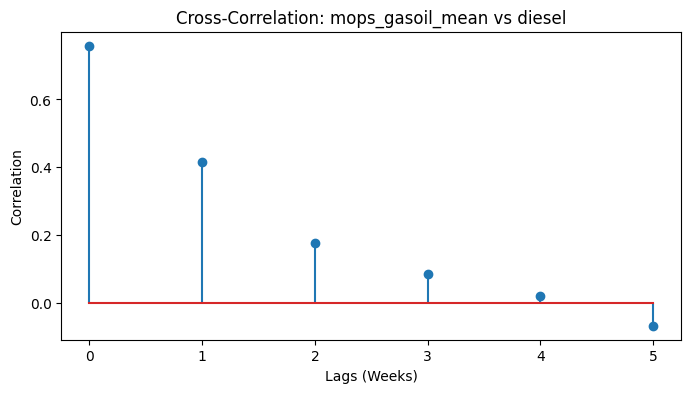

In [10]:
# mops gasoil to diesel
get_ccf_analysis(df, "mops_gasoil_mean", "diesel")

CCF for Target: diesel
     brent_mean  wti_mean  mops_gasoil_mean  mops_rbob_mean  dubai_close
Lag                                                                     
0        0.6292    0.5820            0.7584          0.4855       0.3608
1        0.1899    0.1144            0.4166          0.0273       0.0523
2        0.1648    0.0527            0.1776          0.0280       0.0296
3        0.0342    0.0136            0.0835          0.0254       0.0035
4        0.0056    0.0062            0.0209          0.0115      -0.0204
5       -0.0550   -0.0458           -0.0679         -0.0222       0.0199


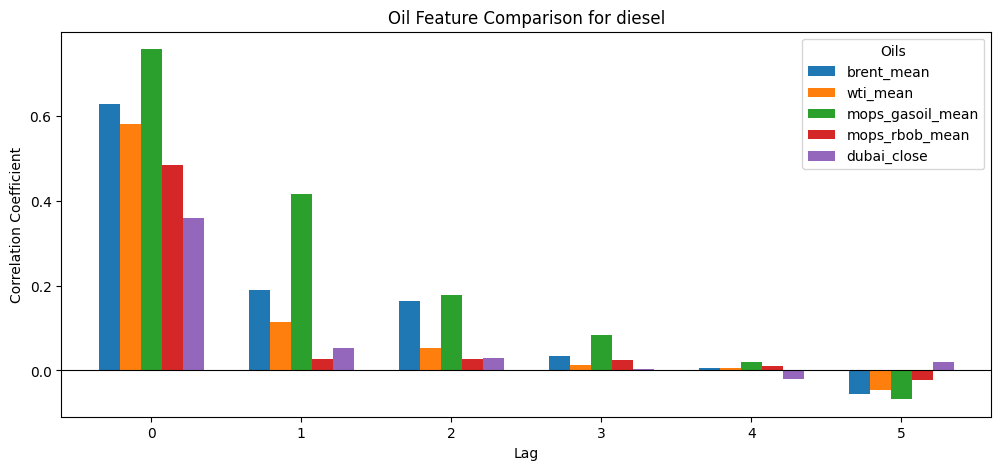

In [11]:
# Execution
oil_features = ['brent_mean', 'wti_mean', 'mops_gasoil_mean', 'mops_rbob_mean', 'dubai_close']
get_oil_feature_mosaic(df, 'diesel', oil_features)

CCF for Target: ron91
     brent_mean  wti_mean  mops_gasoil_mean  mops_rbob_mean  dubai_close
Lag                                                                     
0        0.7251    0.6925            0.7590          0.6964       0.4033
1        0.2041    0.1335            0.3933          0.1197       0.1028
2        0.2046    0.0974            0.2301          0.0602       0.0459
3        0.1370    0.0858            0.1893          0.0385       0.0162
4        0.0241    0.0317            0.0529          0.0003      -0.0092
5       -0.1099   -0.0993           -0.0943         -0.0513       0.0131


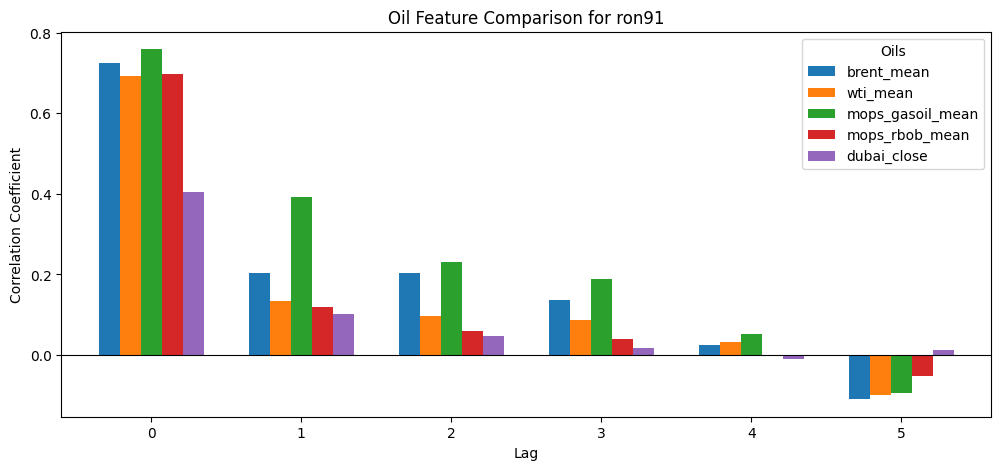

In [12]:
get_oil_feature_mosaic(df, 'ron91', oil_features)

## ACF and PACF — Diesel Price (Primary Target)

ACF and PACF reveal the autocorrelation structure of the price series. High autocorrelation at lag 1 (expected: ~0.95) confirms the 'persistence' baseline is strong, and motivates why MASE (vs. naive persistence) is our primary evaluation metric.

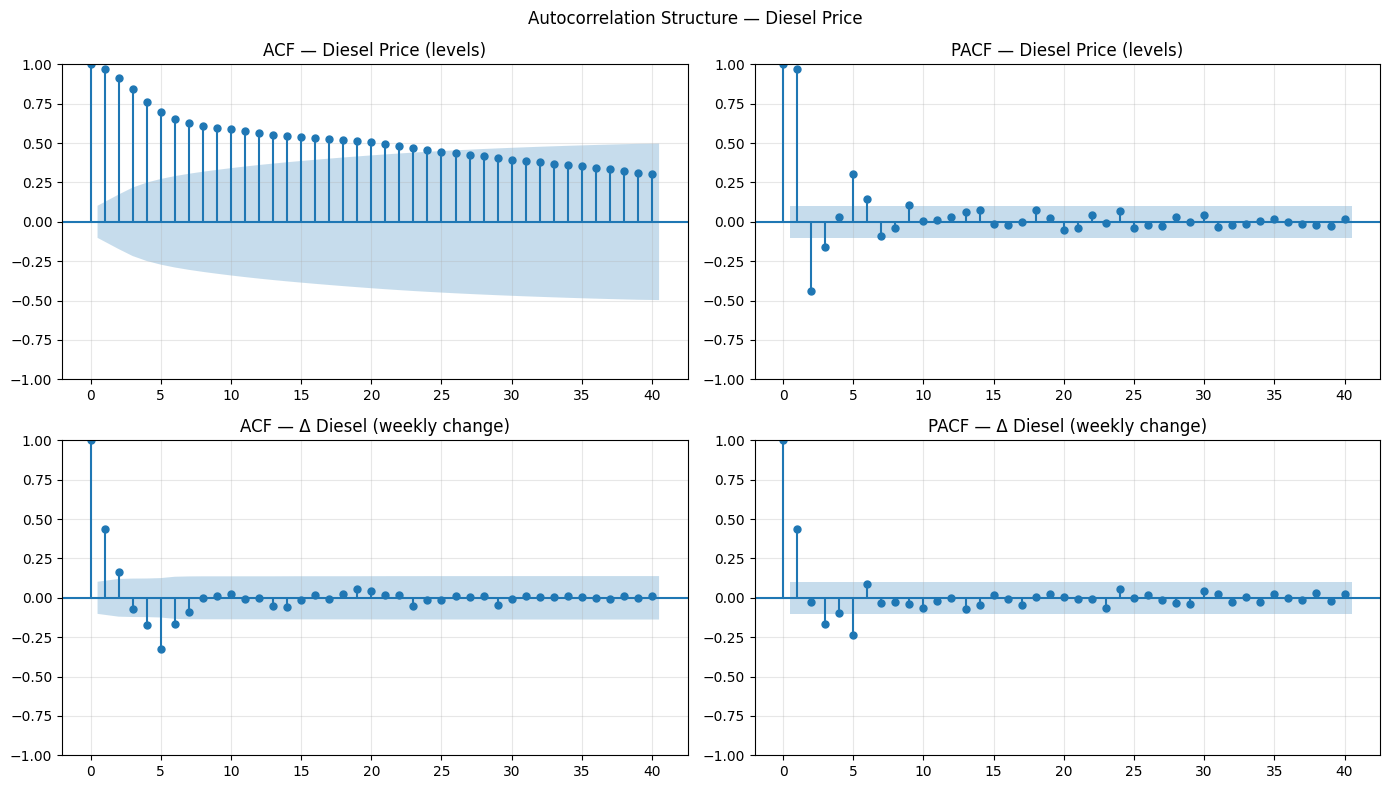

Lag-1 autocorrelation of diesel price: 0.9694
(~0.95 expected — confirms persistence baseline will be hard to beat)


In [13]:
if 'diesel' in df.columns:
    series = df['diesel'].dropna()

    fig, axes = plt.subplots(2, 2, figsize=(14, 8))

    plot_acf(series, lags=40, ax=axes[0,0], title='ACF — Diesel Price (levels)')
    plot_pacf(series, lags=40, ax=axes[0,1], title='PACF — Diesel Price (levels)')
    plot_acf(series.diff().dropna(), lags=40, ax=axes[1,0], title='ACF — Δ Diesel (weekly change)')
    plot_pacf(series.diff().dropna(), lags=40, ax=axes[1,1], title='PACF — Δ Diesel (weekly change)')

    for ax in axes.flat:
        ax.grid(True, alpha=0.3)

    plt.suptitle('Autocorrelation Structure — Diesel Price')
    plt.tight_layout()
    plt.show()

    lag1_acf = acf(series.dropna(), nlags=1)[1]
    print(f'Lag-1 autocorrelation of diesel price: {lag1_acf:.4f}')
    print('(~0.95 expected — confirms persistence baseline will be hard to beat)')

## Asymmetric Price Transmission: "Rockets and Feathers"

Beyond simple correlation, the data reveals significant Asymmetric Price Transmission. This market dynamic, colloquially known as "Rockets and Feathers," describes a scenario where domestic prices rise rapidly in response to international shocks but descend slowly when costs decrease.

Particularly, an Asymmetry Ratio of 1.38x proves that the local diesel market is mathematically "stickier" on the way down. While pump prices surge like rockets to protect refinery margins during international upticks, they drift down like feathers when global benchmarks cool.

In [14]:
# Create a lagged version of MOPS change
df["mops_change_lag1"] = df["mops_gasoil_mean"].diff().shift(1)
df["diesel_change"] = df["diesel"].diff()

# Filter based on the PREVIOUS week's move
up_weeks   = df[df["mops_change_lag1"] > 0]["diesel_change"].dropna()
down_weeks = df[df["mops_change_lag1"] < 0]["diesel_change"].dropna()

print(f"Rockets and Feathers (Lagged Analysis)")
print(f"MOPS Rose (n={len(up_weeks)})   -> Avg Diesel Rise: {up_weeks.mean():.4f}")
print(f"MOPS Fell (n={len(down_weeks)}) -> Avg Diesel Fall: {down_weeks.mean():.4f}")

# Asymmetry Ratio
ratio = abs(up_weeks.mean() / down_weeks.mean())
print(f"Asymmetry Ratio: {ratio:.2f}x") 
# A ratio > 1.0 means 'Rockets' are real.

Rockets and Feathers (Lagged Analysis)
MOPS Rose (n=204)   -> Avg Diesel Rise: 0.5200
MOPS Fell (n=163) -> Avg Diesel Fall: -0.3773
Asymmetry Ratio: 1.38x


## Time series plots

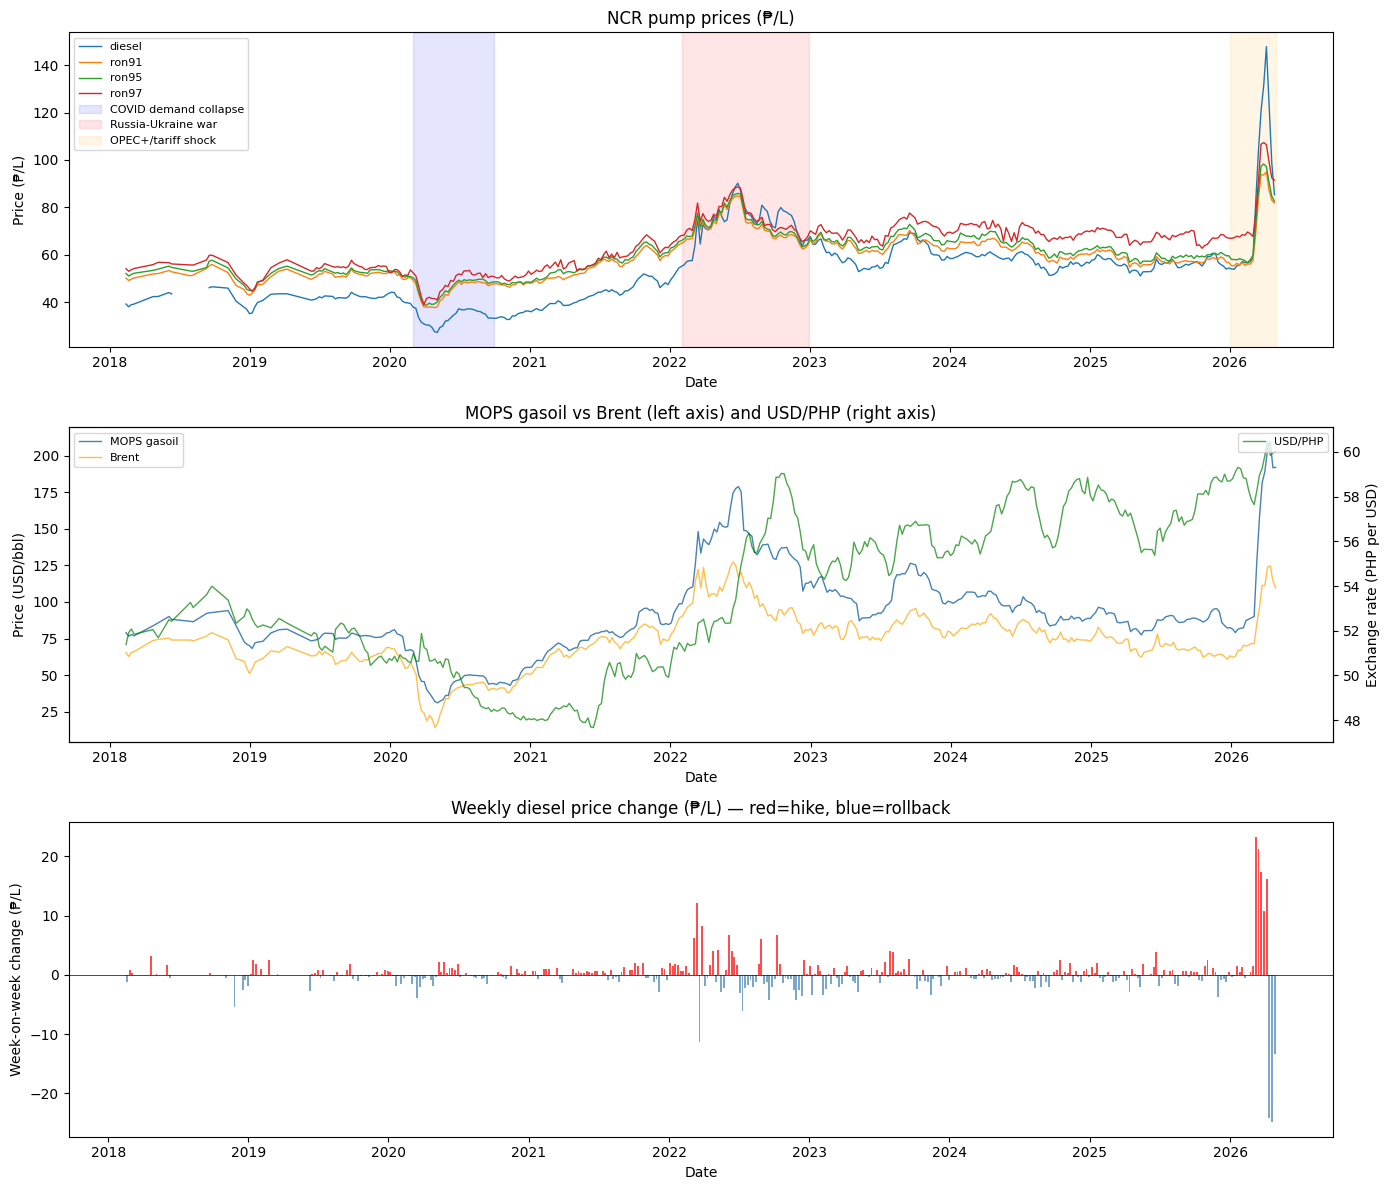

In [15]:
fig, axes = plt.subplots(3, 1, figsize=(14, 12))

# Panel 1: Pump prices
ax = axes[0]
for col in ["diesel", "ron91", "ron95", "ron97"]:
    ax.plot(df.index, df[col], label=col, linewidth=1)
ax.axvspan("2020-03-01", "2020-09-30", alpha=0.1, color="blue",   label="COVID demand collapse")
ax.axvspan("2022-02-01", "2022-12-31", alpha=0.1, color="red",    label="Russia-Ukraine war")
ax.axvspan("2026-01-01", "2026-04-30", alpha=0.1, color="orange", label="OPEC+/tariff shock")
ax.set_title("NCR pump prices (₱/L)")
ax.set_xlabel("Date")
ax.set_ylabel("Price (₱/L)")
ax.legend(loc="upper left", fontsize=8)

# Panel 2: Features
ax = axes[1]
ax2 = ax.twinx()
ax.plot(df.index, df["mops_gasoil_mean"], color="steelblue", label="MOPS gasoil", linewidth=1)
ax.plot(df.index, df["brent_mean"],       color="orange",    label="Brent",       linewidth=1, alpha=0.7)
ax2.plot(df.index, df["usd_php_mean"],    color="green",     label="USD/PHP",     linewidth=1, alpha=0.7)
ax.set_title("MOPS gasoil vs Brent (left axis) and USD/PHP (right axis)")
ax.set_xlabel("Date")
ax.set_ylabel("Price (USD/bbl)")
ax2.set_ylabel("Exchange rate (PHP per USD)")
ax.legend(loc="upper left", fontsize=8)
ax2.legend(loc="upper right", fontsize=8)

# Panel 3: Weekly changes
ax = axes[2]
ax.bar(df.index, df["diesel_change"],
       color=np.where(df["diesel_change"] >= 0, "red", "steelblue"),
       width=5, alpha=0.7)
ax.axhline(0, color="black", linewidth=0.5)
ax.set_title("Weekly diesel price change (₱/L) — red=hike, blue=rollback")
ax.set_xlabel("Date")
ax.set_ylabel("Week-on-week change (₱/L)")

plt.tight_layout()
plt.show()

## Feature correlation matrix

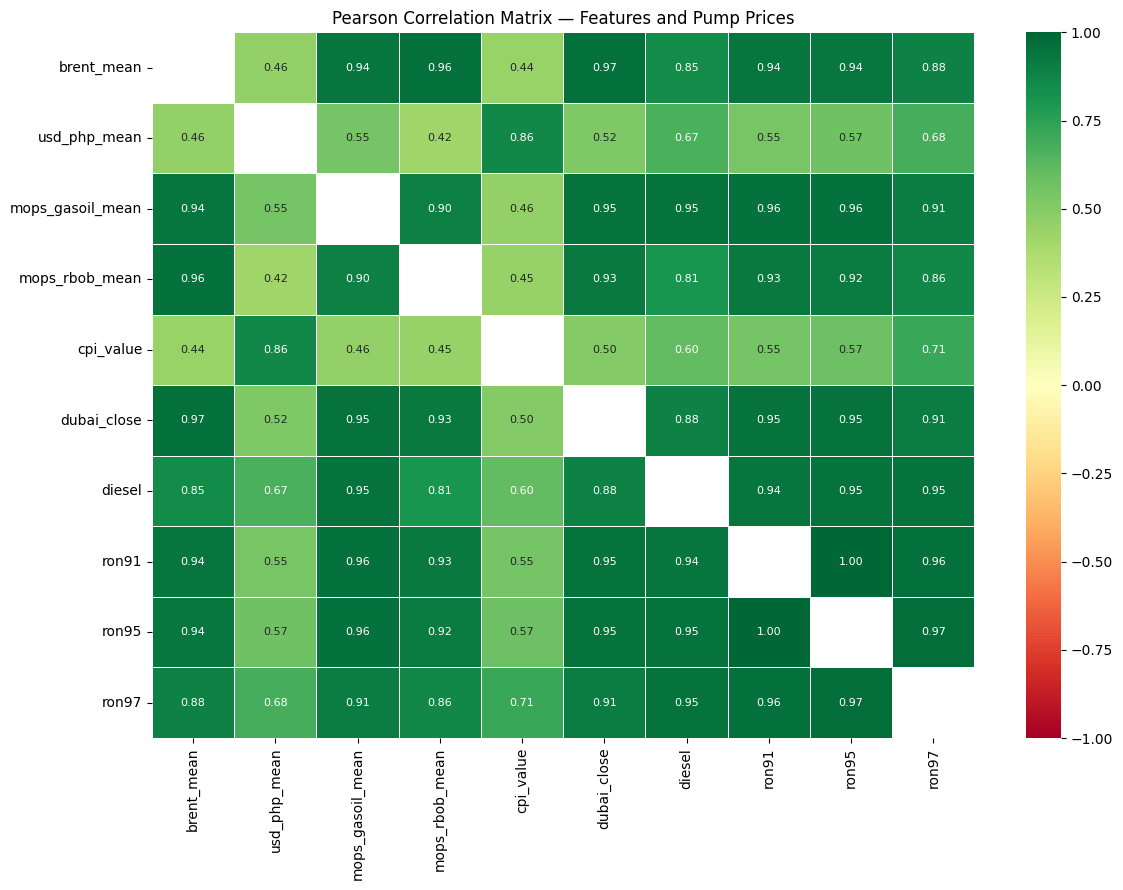

In [16]:
analysis_cols = feat_available + available_products
corr_df = df[analysis_cols].dropna()
corr_matrix = corr_df.corr()

fig, ax = plt.subplots(figsize=(12, 9))
mask = np.zeros_like(corr_matrix, dtype=bool)
np.fill_diagonal(mask, True)
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdYlGn',
            vmin=-1, vmax=1, ax=ax, mask=mask,
            annot_kws={'size': 8}, linewidths=0.5)
ax.set_title('Pearson Correlation Matrix — Features and Pump Prices')
plt.tight_layout()
plt.show()